您可以從 [Bookshop.org](https://bookshop.org/a/98697/9781098155438) 和 [Amazon](https://www.amazon.com/_/dp/1098155432?smid=ATVPDKIKX0DER&_encoding=UTF8&tag=oreilly20-20&_encoding=UTF8&tag=greenteapre01-20&linkCode=ur2&linkId=e2a529f94920295d27ec8a06e757dc7c&camp=1789&creative=9325) 訂購《Think Python 3e》的印刷版和電子書版本。

In [ ]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + str(local))
    return filename

download('https://github.com/AllenDowney/ThinkPython/raw/v3/thinkpython.py');
download('https://github.com/AllenDowney/ThinkPython/raw/v3/diagram.py');
download('https://github.com/ramalho/jupyturtle/releases/download/2024-03/jupyturtle.py');

import thinkpython

: 

# 條件句與遞迴

本章的主要主題是 `if` 陳述句，它會根據程式的狀態執行不同的程式碼。
透過 `if` 陳述句，我們能夠探索計算中最強大的概念之一：**遞迴**。

但我們先從三個新功能開始：模數運算子、布林運算式和邏輯運算子。

## 整數除法與模數

回憶一下，整數除法運算子 `//` 會將兩個數字相除並無條件捨去至整數。
例如，假設一部電影的播放時間是 105 分鐘。
您可能想知道這相當於多少小時。
傳統除法會回傳浮點數：

In [2]:
minutes = 105
minutes / 60

1.75

但我們通常不會用小數點來表示小時數。
整數除法會回傳小時的整數，無條件捨去：

In [3]:
minutes = 105
hours = minutes // 60
hours

1

要得到餘數，您可以減去一個小時的分鐘數：

In [4]:
remainder = minutes - hours * 60
remainder

45

或者您可以使用**模數運算子** `%`，它會將兩個數字相除並回傳餘數。

In [5]:
remainder = minutes % 60
remainder

45

模數運算子比看起來更有用。
例如，它可以檢查一個數字是否能被另一個數字整除——如果 `x % y` 是零，那麼 `x` 可以被 `y` 整除。

此外，它可以從一個數字中提取最右邊的數字。
例如，`x % 10` 會得到 `x` 的最右邊數字（十進位制）。
同樣地，`x % 100` 會得到最後兩位數字。

In [2]:
x = 123
x % 10

3

In [3]:
x % 100

23

最後，模數運算子可以進行「時鐘運算」。
例如，如果一個活動從上午 11 點開始，持續三個小時，我們可以使用模數運算子來計算它的結束時間。

In [1]:
start = 11
duration = 3
end = (start + duration) % 12
end

2

這個活動會在下午 2 點結束。

## 布林運算式

**布林運算式**是一個其值不是真就是假的運算式。
例如，下列運算式使用等於運算子 `==`，它會比較兩個值，如果它們相等就產生 `True`，否則產生 `False`：

In [8]:
5 == 5

True

In [9]:
5 == 7

False

常見的錯誤是使用單一等號（`=`）而不是雙等號（`==`）。
記住 `=` 是為變數賦值，而 `==` 是比較兩個值。

In [10]:
x = 5
y = 7

In [11]:
x == y

False

`True` 和 `False` 是屬於 `bool` 型別的特殊值；它們不是字串：

In [12]:
type(True)

bool

In [13]:
type(False)

bool

`==` 運算子是**關係運算子**之一；其他的還有：

In [ ]:
x != y               # x 不等於 y

In [ ]:
x > y                # x 大於 y

In [ ]:
x < y               # x 小於 y

In [ ]:
x >= y               # x 大於或等於 y

In [ ]:
x <= y               # x 小於或等於 y

## 邏輯運算子

要將布林值組合成運算式，我們可以使用**邏輯運算子**。
最常見的是 `and`、`or` 和 `not`。
這些運算子的意義與它們在英文中的意義相似。
例如，下列運算式的值只有在 `x` 大於 `0` *且*小於 `10` 時才是 `True`。

In [19]:
x > 0 and x < 10

True

如果*其中一個或兩個*條件都為真，下列運算式就是 `True`，也就是說，如果數字能被 2 *或* 3 整除：

In [20]:
x % 2 == 0 or x % 3 == 0

False

最後，`not` 運算子會否定一個布林運算式，所以如果 `x > y` 是 `False`，下列運算式就是 `True`。

In [21]:
not x > y

True

嚴格來說，邏輯運算子的運算元應該是布林運算式，但 Python 並不是很嚴格。
任何非零數字都被解釋為 `True`：

In [22]:
42 and True

True

這種彈性很有用，但其中有一些微妙之處可能會令人困惑。
您可能會想要避免使用它。

## if 陳述句

為了撰寫有用的程式，我們幾乎總是需要能夠檢查條件並相應地改變程式的行為。
**條件陳述句**賦予我們這種能力。最簡單的形式是 `if` 陳述句：

In [23]:
if x > 0:
    print('x is positive')

x is positive


`if` 是 Python 的關鍵字。
`if` 陳述句與函數定義有相同的結構：一個標頭後面跟著一個縮排的陳述句或一系列陳述句，稱為**區塊**。

`if` 後面的布林運算式稱為**條件**。
如果它是真的，縮排區塊中的陳述句就會執行。如果不是，它們就不會執行。

區塊中可以出現的陳述句數量沒有限制，但至少要有一個。
偶爾，有一個什麼都不做的區塊是有用的——通常是作為您尚未撰寫的程式碼的佔位符。
在這種情況下，您可以使用 `pass` 陳述句，它什麼都不做。

In [ ]:
if x < 0:
    pass          # TODO: 需要處理負值！

註解中的 `TODO` 一詞是一個慣例性提醒，表示您稍後需要做某事。

## `else` 子句

`if` 陳述句可以有第二個部分，稱為 `else` 子句。
語法如下：

In [ ]:
if x % 2 == 0:
    print('x 是偶數')
else:
    print('x 是奇數')

如果條件為真，第一個縮排陳述句會執行；否則，第二個縮排陳述句會執行。

在這個例子中，如果 `x` 是偶數，`x` 除以 `2` 的餘數是 `0`，所以條件為真，程式顯示 `x 是偶數`。
如果 `x` 是奇數，餘數是 `1`，所以條件為假，程式顯示 `x 是奇數`。

由於條件必須是真或假，因此恰好有一個替代方案會執行。
這些替代方案稱為**分支**。

## 串聯條件句

有時候有超過兩種可能性，我們需要超過兩個分支。
表達這種計算的一種方法是**串聯條件句**，它包含 `elif` 子句。

In [ ]:
if x < y:
    print('x 小於 y')
elif x > y:
    print('x 大於 y')
else:
    print('x 和 y 相等')

`elif` 是「else if」的縮寫。
`elif` 子句的數量沒有限制。
如果有 `else` 子句，它必須在最後，但不是必須要有。

每個條件都會按順序檢查。
如果第一個是假的，就檢查下一個，依此類推。
如果其中一個為真，對應的分支就會執行，`if` 陳述句就結束。
即使有多個條件為真，也只有第一個為真的分支會執行。

## 巢狀條件句

一個條件句也可以巢狀於另一個條件句中。
我們可以像這樣撰寫前一節的例子：

In [ ]:
if x == y:
    print('x 和 y 相等')
else:
    if x < y:
        print('x 小於 y')
    else:
        print('x 大於 y')

外層的 `if` 陳述句包含兩個分支。
第一個分支包含一個簡單陳述句。第二個分支包含另一個 `if` 陳述句，它有自己的兩個分支。
這兩個分支都是簡單陳述句，儘管它們也可以是條件陳述句。

雖然陳述句的縮排使結構變得明顯，但**巢狀條件句**可能很難閱讀。
我建議您在可能的情況下避免使用它們。

邏輯運算子通常提供一種簡化巢狀條件陳述句的方法。
這裡是一個巢狀條件句的例子。

In [ ]:
if 0 < x:
    if x < 10:
        print('x 是正的個位數。')

`print` 陳述句只有在我們通過兩個條件句時才會執行，所以我們使用 `and` 運算子可以得到相同的效果。

In [ ]:
if 0 < x and x < 10:
    print('x 是正的個位數。')

對於這種條件，Python 提供了更簡潔的選項：

In [ ]:
if 0 < x < 10:
    print('x 是正的個位數。')

## 遞迴

函數呼叫自己是合法的。
這可能不明顯為什麼是件好事，但事實證明這是程式能做的最神奇的事情之一。
這裡是一個例子。

In [31]:
def countdown(n):
    if n <= 0:
        print('Blastoff!')
    else:
        print(n)
        countdown(n-1)

如果 `n` 是 0 或負數，`countdown` 輸出「Blastoff!」這個字。否則，它輸出 `n`，然後呼叫自己，傳遞 `n-1` 作為引數。

以下是當我們用引數 `3` 呼叫這個函數時會發生什麼。

In [32]:
countdown(3)

3
2
1
Blastoff!


`countdown` 的執行從 `n=3` 開始，由於 `n` 大於 `0`，它顯示 `3`，然後呼叫自己...

> `countdown` 的執行從 `n=2` 開始，由於 `n` 大於 `0`，它顯示 `2`，然後呼叫自己...
>
> > `countdown` 的執行從 `n=1` 開始，由於 `n` 大於 `0`，它顯示 `1`，然後呼叫自己...
> >
> > > `countdown` 的執行從 `n=0` 開始，由於 `n` 不大於 `0`，它顯示「Blastoff!」並回傳。
> >
> > 得到 `n=1` 的 `countdown` 回傳。
>
> 得到 `n=2` 的 `countdown` 回傳。

得到 `n=3` 的 `countdown` 回傳。

呼叫自己的函數是**遞迴的**。
作為另一個例子，我們可以撰寫一個函數，將字串列印 `n` 次。

In [33]:
def print_n_times(string, n):
    if n > 0:
        print(string)
        print_n_times(string, n-1)

如果 `n` 是正數，`print_n_times` 顯示 `string` 的值，然後呼叫自己，傳遞 `string` 和 `n-1` 作為引數。

如果 `n` 是 `0` 或負數，條件為假，`print_n_times` 什麼都不做。

以下是它的運作方式。

In [34]:
print_n_times('Spam ', 4)

Spam 
Spam 
Spam 
Spam 


對於像這樣的簡單例子，使用 `for` 迴圈可能更容易。但我們稍後會看到一些用 `for` 迴圈很難撰寫但用遞迴很容易撰寫的例子，所以及早開始是好的。

## 遞迴函數的堆疊圖

這裡是一個堆疊圖，顯示當我們用 `n = 3` 呼叫 `countdown` 時所建立的框架。

In [35]:
from diagram import make_frame, Stack

frames = []
for n in [3,2,1,0]:
    d = dict(n=n)
    frame = make_frame(d, name='countdown', dy=-0.3, loc='left')
    frames.append(frame)

stack = Stack(frames, dy=-0.5)

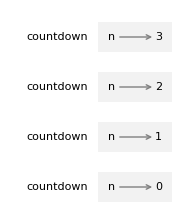

In [36]:
from diagram import diagram, adjust


width, height, x, y = [1.74, 2.04, 1.05, 1.77]
ax = diagram(width, height)
bbox = stack.draw(ax, x, y)
# adjust(x, y, bbox)

四個 `countdown` 框架對參數 `n` 有不同的值。
堆疊的底部，其中 `n=0`，稱為**基底情況**。
它不進行遞迴呼叫，所以沒有更多的框架。

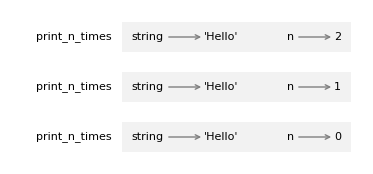

In [37]:
from diagram import make_frame, Stack
from diagram import diagram, adjust

frames = []
for n in [2,1,0]:
    d = dict(string='Hello', n=n)
    frame = make_frame(d, name='print_n_times', dx=1.3, loc='left')
    frames.append(frame)

stack = Stack(frames, dy=-0.5)

width, height, x, y = [3.53, 1.54, 1.54, 1.27]
ax = diagram(width, height)
bbox = stack.draw(ax, x, y)
# adjust(x, y, bbox)

## 無窮遞迴

如果遞迴從未到達基底情況，它會一直進行遞迴呼叫，程式永遠不會終止。這被稱為**無窮遞迴**，這通常不是一個好主意。
這裡是一個具有無窮遞迴的最小函數。

In [38]:
def recurse():
    recurse()

每次呼叫 `recurse` 時，它都會呼叫自己，這會建立另一個框架。
在 Python 中，堆疊上同時可以有的框架數量是有限制的。
如果程式超過了限制，就會導致執行時間錯誤。

In [39]:
%xmode Context

Exception reporting mode: Context


In [40]:
%%expect RecursionError

recurse()

RecursionError: maximum recursion depth exceeded

追蹤回溯顯示當錯誤發生時，堆疊上大約有 3000 個框架。

如果您意外遇到無窮遞迴，請檢閱您的函數以確認有一個不進行遞迴呼叫的基底情況。如果有基底情況，請檢查您是否保證會到達它。

## 鍵盤輸入

到目前為止，我們撰寫的程式不接受使用者的任何輸入。它們每次都做同樣的事情。

Python 提供了一個稱為 `input` 的內建函數，它會停止程式並等待使用者輸入某些內容。當使用者按下 *Return* 或 *Enter* 時，程式會繼續，`input` 會將使用者輸入的內容作為字串回傳。

In [ ]:
# 解答

# 這個儲存格替換了 input 函數，讓 notebook 可以不暫停地執行
def input():
     return

In [42]:
text = input()

在從使用者獲取輸入之前，您可能想要顯示一個提示，告訴使用者要輸入什麼。`input` 可以接受一個提示作為引數：

In [ ]:
# 解答

# 這個儲存格替換了 input 函數，讓 notebook 可以不暫停地執行
def input(prompt):
    print(prompt, end='')
    reply = 'It is Arthur, King of the Britons'
    print(reply)
    return reply

In [ ]:
name = input('什麼...是您的名字？\n')
name

提示末尾的序列 `\n` 代表一個**換行字元**，這是一個會在兩個字串部分之間產生換行的特殊字元——這樣使用者的輸入就會出現在提示的下方。

如果您期望使用者輸入一個整數，您可以使用 `int` 函數將回傳值轉換為 `int`。

In [ ]:
# 解答

# 這個儲存格替換了 input 函數，讓 notebook 可以不暫停地執行
def input(prompt):
    print(prompt, end='')
    reply = 'What do you mean: an African or European swallow?'
    print(reply)
    return reply

In [ ]:
prompt = '什麼...是無載燕子的飛行速度？\n'
speed = input(prompt)
speed

但如果他們輸入的不是整數，您會得到執行時間錯誤。

In [47]:
%xmode Minimal

Exception reporting mode: Minimal


In [48]:
%%expect ValueError

int(speed)

ValueError: invalid literal for int() with base 10: 'What do you mean: an African or European swallow?'

我們稍後會看到如何處理這種錯誤。

## 除錯

當語法或執行時間錯誤發生時，錯誤訊息包含很多資訊，但它可能會讓人不知所措。最有用的部分通常是：

- 是什麼類型的錯誤，以及

- 它在哪裡發生。

語法錯誤通常很容易找到，但有一些陷阱。
與空格和分頁符號相關的錯誤可能很棘手，因為它們是不可見的，而我們習慣忽略它們。

In [49]:
%%expect IndentationError
x = 5
 y = 6

IndentationError: unexpected indent (2365500740.py, line 2)

在這個例子中，問題是第二行縮排了一個空格。
但錯誤訊息指向 `y`，這是誤導的。
錯誤訊息指出問題被發現的地方，但實際錯誤可能在程式碼的更早位置。

執行時間錯誤也是如此。
例如，假設您試圖將比率轉換為分貝，像這樣：

In [50]:
%xmode Context

Exception reporting mode: Context


In [51]:
%%expect ValueError
import math
numerator = 9
denominator = 10
ratio = numerator // denominator
decibels = 10 * math.log10(ratio)

ValueError: math domain error

錯誤訊息指出第 5 行，但那一行沒有任何問題。
問題在第 4 行，它使用整數除法而不是浮點除法——結果，`ratio` 的值是 `0`。
當我們呼叫 `math.log10` 時，我們得到一個 `ValueError`，訊息是 `math domain error`，因為 `0` 不在 `math.log10` 的有效引數「定義域」中，因為 `0` 的對數是未定義的。

一般來說，您應該花時間仔細閱讀錯誤訊息，但不要假設它們說的一切都是正確的。

## 詞彙表

**遞迴（recursion）:**
呼叫目前正在執行的函數的過程。

**模數運算子（modulus operator）:**
一個運算子 `%`，它作用於整數並回傳一個數字除以另一個數字的餘數。

**布林運算式（boolean expression）:**
一個其值不是 `True` 就是 `False` 的運算式。

**關係運算子（relational operator）:**
比較其運算元的運算子之一：`==`、`!=`、`>`、`<`、`>=` 和 `<=`。

**邏輯運算子（logical operator）:**
組合布林運算式的運算子之一，包括 `and`、`or` 和 `not`。

**條件陳述句（conditional statement）:**
根據某種條件控制執行流程的陳述句。

**條件（condition）:**
條件陳述句中決定哪個分支執行的布林運算式。

**區塊（block）:**
一個或多個縮排的陳述句，表示它們是另一個陳述句的一部分。

**分支（branch）:**
條件陳述句中替代陳述句序列之一。

**串聯條件句（chained conditional）:**
具有一系列替代分支的條件陳述句。

**巢狀條件句（nested conditional）:**
出現在另一個條件陳述句分支中的條件陳述句。

**遞迴的（recursive）:**
呼叫自己的函數是遞迴的。

**基底情況（base case）:**
遞迴函數中不進行遞迴呼叫的條件分支。

**無窮遞迴（infinite recursion）:**
沒有基底情況或永遠不會到達基底情況的遞迴。
最終，無窮遞迴會導致執行時間錯誤。

**換行字元（newline）:**
在字串的兩個部分之間建立換行的字元。

## 練習

In [ ]:
# 這個儲存格告訴 Jupyter 在發生執行時間錯誤時提供詳細的除錯資訊
# 在進行練習之前先執行它。

%xmode Verbose

### 詢問虛擬助理

* 詢問虛擬助理：「模數運算子有哪些用途？」

* Python 提供運算子來計算邏輯運算 `and`、`or` 和 `not`，但它沒有計算互斥 `or` 運算的運算子，通常寫作 `xor`。詢問助理「什麼是邏輯 xor 運算，我如何在 Python 中計算它？」

在本章中，我們看到了兩種撰寫具有三個分支的 `if` 陳述句的方法，使用串聯條件句或巢狀條件句。
您可以使用虛擬助理從一種轉換為另一種。
例如，詢問 VA：「將這個陳述句轉換為串聯條件句。」

In [53]:
x = 5
y = 7

In [54]:
if x == y:
    print('x and y are equal')
else:
    if x < y:
        print('x is less than y')
    else:
        print('x is greater than y')

x is less than y


詢問 VA：「用單一條件句重寫這個陳述句。」

In [55]:
if 0 < x:
    if x < 10:
        print('x is a positive single-digit number.')

x is a positive single-digit number.


看看 VA 是否能簡化這個不必要的複雜性。

In [56]:
if not x <= 0 and not x >= 10:
    print('x is a positive single-digit number.')

x is a positive single-digit number.


這裡是一個嘗試以二為單位倒數的遞迴函數。

In [57]:
def countdown_by_two(n):
    if n == 0:
        print('Blastoff!')
    else:
        print(n)
        countdown_by_two(n-2)

它似乎可以運作。

In [58]:
countdown_by_two(6)

6
4
2
Blastoff!


但它有一個錯誤。詢問虛擬助理哪裡有問題以及如何修正它。
將它提供的解決方案貼回這裡並測試它。

### 練習

`time` 模組提供了一個函數，也稱為 `time`，它回傳自「Unix 紀元」以來的秒數，也就是 1970 年 1 月 1 日 00:00:00 UTC（協調世界時）。

In [59]:
from time import time

now = time()
now

1716394001.8466134

使用整數除法和模數運算子來計算自 1970 年 1 月 1 日以來的天數以及當前的時、分、秒。

您可以在 <https://docs.python.org/3/library/time.html> 閱讀更多關於 `time` 模組的資訊。

In [ ]:
# 解答

seconds_per_day = 24 * 60 * 60
days = now // seconds_per_day
days

In [ ]:
# 解答

remainder = now % seconds_per_day

hours = remainder // 3600
hours

In [ ]:
# 解答

remainder = remainder % 3600

minutes = remainder // 60
minutes

In [ ]:
# 解答

seconds = remainder % 60
seconds

### 練習

如果給您三根棍子，您可能無法將它們排列成三角形。例如，如果其中一根棍子長 12 英寸，其他兩根長 1 英寸，您將無法讓短棍子在中間相遇。對於任何三個長度，有一個測試來檢查是否可能形成三角形：

> 如果三個長度中任何一個大於其他兩個的總和，那麼您無法形成三角形。否則，您可以。（如果兩個長度的總和等於第三個，它們形成所謂的「退化」三角形。）

撰寫一個名為 `is_triangle` 的函數，它接受三個整數作為引數，並根據您是否能用給定長度的棍子形成三角形，列印「Yes」或「No」。提示：使用串聯條件句。


In [ ]:
# 解答

def is_triangle(a, b, c):
    if a > b + c:
        print('No')
    elif b > a + c:
        print('No')
    elif c > a + b:
        print('No')
    else:
        print('Yes')

用以下情況測試您的函數。

In [ ]:
is_triangle(4, 5, 6)   # 應該是 Yes

In [ ]:
is_triangle(1, 2, 3)   # 應該是 Yes

In [ ]:
is_triangle(6, 2, 3)   # 應該是 No

In [ ]:
is_triangle(1, 1, 12)   # 應該是 No

### 練習

以下程式的輸出是什麼？畫一個堆疊圖，顯示程式列印結果時的狀態。

In [69]:
def recurse(n, s):
    if n == 0:
        print(s)
    else:
        recurse(n-1, n+s)

recurse(3, 0)

6


In [ ]:
# 解答

"""將從 1 到 `n` 的數字加總

n: 整數
s: 到目前為止的數字總和
"""

In [ ]:
# 解答

from diagram import make_frame, Stack
from diagram import diagram, adjust

frames = []
for n in [3,2,1,0]:
    d = dict(n=n, s=6-sum(range(n+1)))
    frame = make_frame(d, name='recurse', dx=1.0, loc='left')
    frames.append(frame)

stack = Stack(frames, dy=-0.5)

width, height, x, y = [2.49, 2.04, 0.81, 1.77]
ax = diagram(width, height)
bbox = stack.draw(ax, x, y)
# adjust(x, y, bbox)

### 練習

以下練習使用 `jupyturtle` 模組，在第 4 章中有說明。

閱讀以下函數，看看您能否弄清楚它的作用。
然後執行它，看看您是否答對了。
調整 `length`、`angle` 和 `factor` 的值，看看它們對結果有什麼影響。
如果您不確定它是如何運作的，請嘗試詢問虛擬助理。

In [72]:
from jupyturtle import forward, left, right, back

def draw(length):
    angle = 50
    factor = 0.6

    if length > 5:
        forward(length)
        left(angle)
        draw(factor * length)
        right(2 * angle)
        draw(factor * length)
        left(angle)
        back(length)

In [ ]:
# 解答

from jupyturtle import make_turtle

make_turtle(delay=0)
draw(50)

### 練習

詢問虛擬助理「什麼是科赫曲線？」

要繪製長度為 `x` 的科赫曲線，您只需要：

1. 繪製長度為 `x/3` 的科赫曲線。

2. 向左轉 60 度。

3. 繪製長度為 `x/3` 的科赫曲線。

4. 向右轉 120 度。

5. 繪製長度為 `x/3` 的科赫曲線。

6. 向左轉 60 度。

7. 繪製長度為 `x/3` 的科赫曲線。

例外是如果 `x` 小於 `5`——在這種情況下，您可以只繪製長度為 `x` 的直線。

撰寫一個稱為 `koch` 的函數，它接受 `x` 作為引數並繪製給定長度的科赫曲線。

In [ ]:
# 解答

def koch(x):
    """繪製長度為 n 的科赫曲線。"""
    if x < 5:
        forward(x)
    else:
        koch(x / 3)
        left(60)
        koch(x / 3)
        right(120)
        koch(x / 3)
        left(60)
        koch(x / 3)

結果應該看起來像這樣：

In [75]:
make_turtle(delay=0)
koch(120)

一旦您讓 koch 運作，您可以使用此迴圈以雪花的形狀繪製三條科赫曲線。

In [76]:
make_turtle(delay=0, height=300)
for i in range(3):
    koch(120)
    right(120)

### 練習

虛擬助理知道 `jupyturtle` 模組中的函數，但這些函數有許多版本，具有不同的名稱，因此 VA 可能不知道您在談論哪一個。

要解決這個問題，您可以在提問前提供額外的資訊。
例如，您可以以「這裡是一個使用 `jupyturtle` 模組的程式，」開始提示，然後貼上本章的其中一個例子。
之後，VA 應該能夠產生使用此模組的程式碼。

作為例子，詢問 VA 一個繪製謝爾賓斯基三角形的程式。
您得到的程式碼應該是一個好的起點，但您可能需要進行一些除錯。
如果第一次嘗試不成功，您可以告訴 VA 發生了什麼並尋求幫助——或者您可以自己除錯。

In [ ]:
# 解答

# 這是我在 2023 年 6 月從 ChatGPT 得到的程式碼，只做了一些修正

def draw_sierpinski(length, depth):
    if depth == 0:
        for _ in range(3):
            forward(length)
            left(120)
    else:
        draw_sierpinski(length / 2, depth - 1)
        forward(length / 2)
        draw_sierpinski(length / 2, depth - 1)
        back(length / 2)
        left(60)
        forward(length / 2)
        right(60)
        draw_sierpinski(length / 2, depth - 1)
        left(60)
        back(length / 2)
        right(60)

結果可能看起來像這樣，儘管您得到的版本可能不同。

In [78]:
make_turtle(delay=0, height=200)

draw_sierpinski(100, 3)

[Think Python: 第三版](https://allendowney.github.io/ThinkPython/index.html)

版權所有 2024 [Allen B. Downey](https://allendowney.com)

程式碼授權：[MIT License](https://mit-license.org/)

文字授權：[Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)